# Hierarchical RDM Parameter Recovery Analysis

Analyzes SMC output from `scripts/parameter_recovery_hierarchical.py`.
Particles are stored in unconstrained flat space and must be transformed
back to interpretable parameters via the TFP bijector.

In [34]:
import arviz as az
import blackjax
import jax
import jax.flatten_util as jfu
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tensorflow_probability.substrates.jax import bijectors as tfb
from tensorflow_probability.substrates.jax import distributions as tfd

from confrdm.data import load_hdf5
from confrdm_jax.plots import plot_data_hist

jax.config.update("jax_enable_x64", True)

## 1. Load results and configure

In [35]:
# --- User config ---
# RESULTS_PATH = "../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/parameter_recovery_hierarchical.hdf5"
RESULTS_PATH = "../outputs/crdm/model.num_bins=12/model.num_mid=128/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/train_steps=1000000/parameter_recovery_hierarchical.hdf5"
NUM_POPULATIONS = 1
NUM_SUBJECTS = 10
P = 7  # per-subject parameters

# SUBJ_PARAM_NAMES = ["v_intercept", "v_slope", "s_true", "b", "t0"]
SUBJ_PARAM_NAMES = ["v_c_intercept", "v_c_slope", "amp", "tau", "s_true", "b", "t0"]
MU_PARAM_NAMES = [f"mu_{n}" for n in SUBJ_PARAM_NAMES]
S_PARAM_NAMES = [f"s_{n}" for n in SUBJ_PARAM_NAMES]

results = load_hdf5(RESULTS_PATH)
print("Keys:", sorted(results.keys()))

Keys: ['pop0_data', 'pop0_log_weights_approx', 'pop0_particles_approx', 'pop0_true_mu', 'pop0_true_psi_raw', 'pop0_true_s', 'pop0_true_theta']


## 2. Reconstruct bijector and unravel function

We need the same bijector and pytree structure used during inference
to map flat unconstrained particles back to interpretable parameters.

In [37]:
bijector = tfb.JointMap({
    "s": tfb.Exp(),
    "mu": tfb.Identity(),
    "psi_raw": tfb.CorrelationCholesky(),
    "theta": tfb.Identity(),
})

# Build a template pytree to create the unravel function.
# The structure must match what the recovery script produces.
template = {
    "s": jnp.zeros(P),
    "mu": jnp.zeros(P),
    "psi_raw": jnp.zeros((P, P)),
    "theta": jnp.zeros((NUM_SUBJECTS, P)),
}
template_unconstrained = bijector.inverse(template)
_, unravel_fn = jfu.ravel_pytree(template_unconstrained)


def particles_to_params(flat_particles):
    """Convert array of flat unconstrained particles to constrained parameter dicts.

    Args:
        flat_particles: (N, D) array of unconstrained flat particles.

    Returns:
        Dict of arrays, each with leading dimension N.
    """
    def transform_one(x):
        return bijector.forward(unravel_fn(x))
    return jax.vmap(transform_one)(flat_particles)


def params_to_theta(params):
    """Reconstruct subject-level theta from non-centered params.

    Args:
        params: dict with 's', 'mu', 'psi_raw', 'z' (batched over particles).

    Returns:
        theta: (N, S, P) array in natural (exp) space.
        log_theta: (N, S, P) array in log space.
    """
    log_theta = params["theta"]
    return jnp.exp(log_theta), log_theta


def params_to_corr(params):
    """Compute correlation matrix from Cholesky factor.

    Args:
        params: dict with 'psi_raw' of shape (N, P, P).

    Returns:
        (N, P, P) correlation matrices.
    """
    L = params["psi_raw"]
    return jnp.einsum("bij,bkj->bik", L, L)


print(f"Flat param dimension: {jfu.ravel_pytree(template_unconstrained)[0].shape[0]}")

Flat param dimension: 105


## 3. Transform particles for each population

In [39]:
populations = {}

for pop_idx in range(NUM_POPULATIONS):
    prefix = f"pop{pop_idx}"
    particles_raw = results[f"{prefix}_particles_approx"]  # (chains, particles, D)
    weights_raw = results[f"{prefix}_log_weights_approx"]  # (chains, particles)

    num_chains, num_particles, D = particles_raw.shape
    print(f"Pop {pop_idx}: {num_chains} chains x {num_particles} particles x {D} params")

    # Merge chains: (chains * particles, D)
    flat_all = particles_raw.reshape(-1, D)

    # Normalize weights across merged particles
    log_w_all = weights_raw.reshape(-1)
    log_w_all = log_w_all - np.max(log_w_all)  # numerical stability
    w_all = np.exp(log_w_all)
    w_all = w_all / w_all.sum()

    # Transform to constrained space
    params = particles_to_params(jnp.array(flat_all))
    params_np = jax.tree.map(np.asarray, params)

    # Derived quantities
    theta, log_theta = params_to_theta(params)
    corr = params_to_corr(params)

    # True values
    true_s = results[f"{prefix}_true_s"]
    true_mu = results[f"{prefix}_true_mu"]
    true_psi_raw = results[f"{prefix}_true_psi_raw"]
    true_psi = true_s[:, None] * true_psi_raw
    true_log_theta = results[f"{prefix}_true_theta"]
    true_theta = np.exp(true_log_theta)
    true_corr = true_psi_raw @ true_psi_raw.T

    populations[pop_idx] = {
        "particles_raw": particles_raw,
        "weights_raw": weights_raw,
        "w": w_all,
        "params": params_np,
        "theta": np.asarray(theta),
        "log_theta": np.asarray(log_theta),
        "corr": np.asarray(corr),
        "true_s": true_s,
        "true_mu": true_mu,
        "true_theta": true_theta,
        "true_log_theta": true_log_theta,
        "true_corr": true_corr,
        "data": results[f"{prefix}_data"],
    }

print("Done.")

Pop 0: 4 chains x 1000 particles x 105 params
Done.


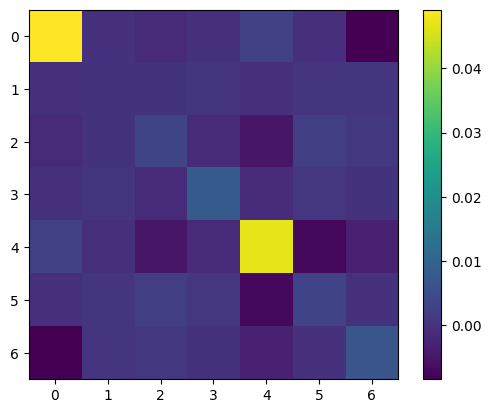

In [64]:
cov_mat = jnp.diag(true_s) @ true_corr @ jnp.diag(true_s)
plt.imshow(cov_mat)
plt.colorbar()

In [67]:
np.array(cov_mat).min()

np.float64(-0.00844171435364493)

In [68]:
true_s

array([0.22166955, 0.00823097, 0.05955529, 0.08913621, 0.21689462,
       0.05635947, 0.08142737])

In [40]:
params_np["mu"].shape

(4000, 7)

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'psi_raw'}>,
        <Axes: title={'center': 'psi_raw'}>],
       [<Axes: title={'center': 's'}>, <Axes: title={'center': 's'}>],
       [<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>]], dtype=object)

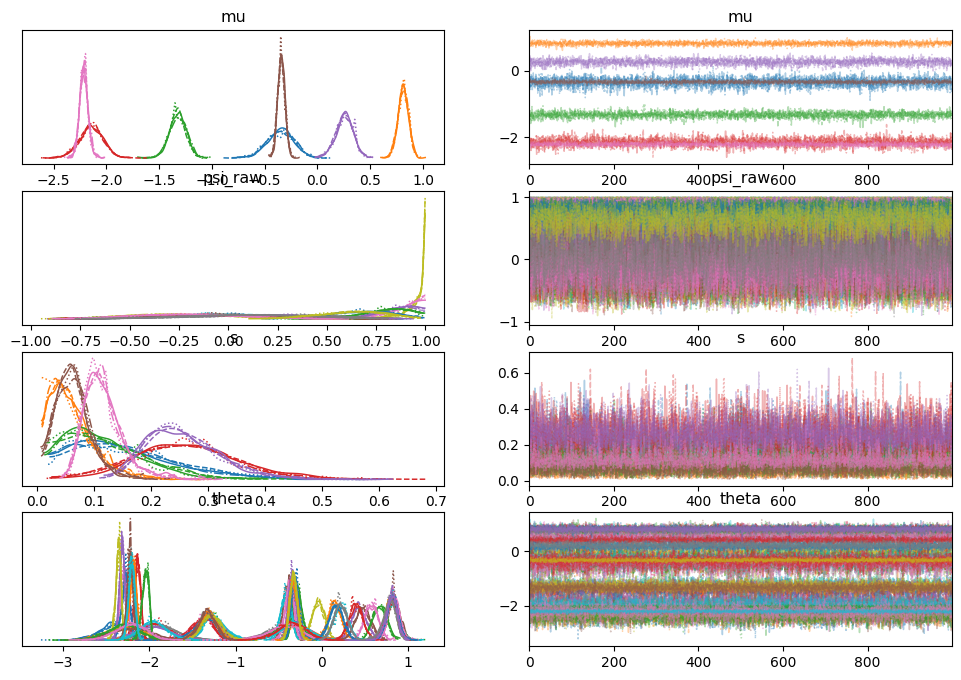

In [41]:
idata = az.convert_to_inference_data({key: val.reshape((4, 1000, -1)) for key, val in params_np.items()})

az.plot_trace(idata)

In [42]:
true_theta.shape, theta.shape

((10, 7), (4000, 10, 7))

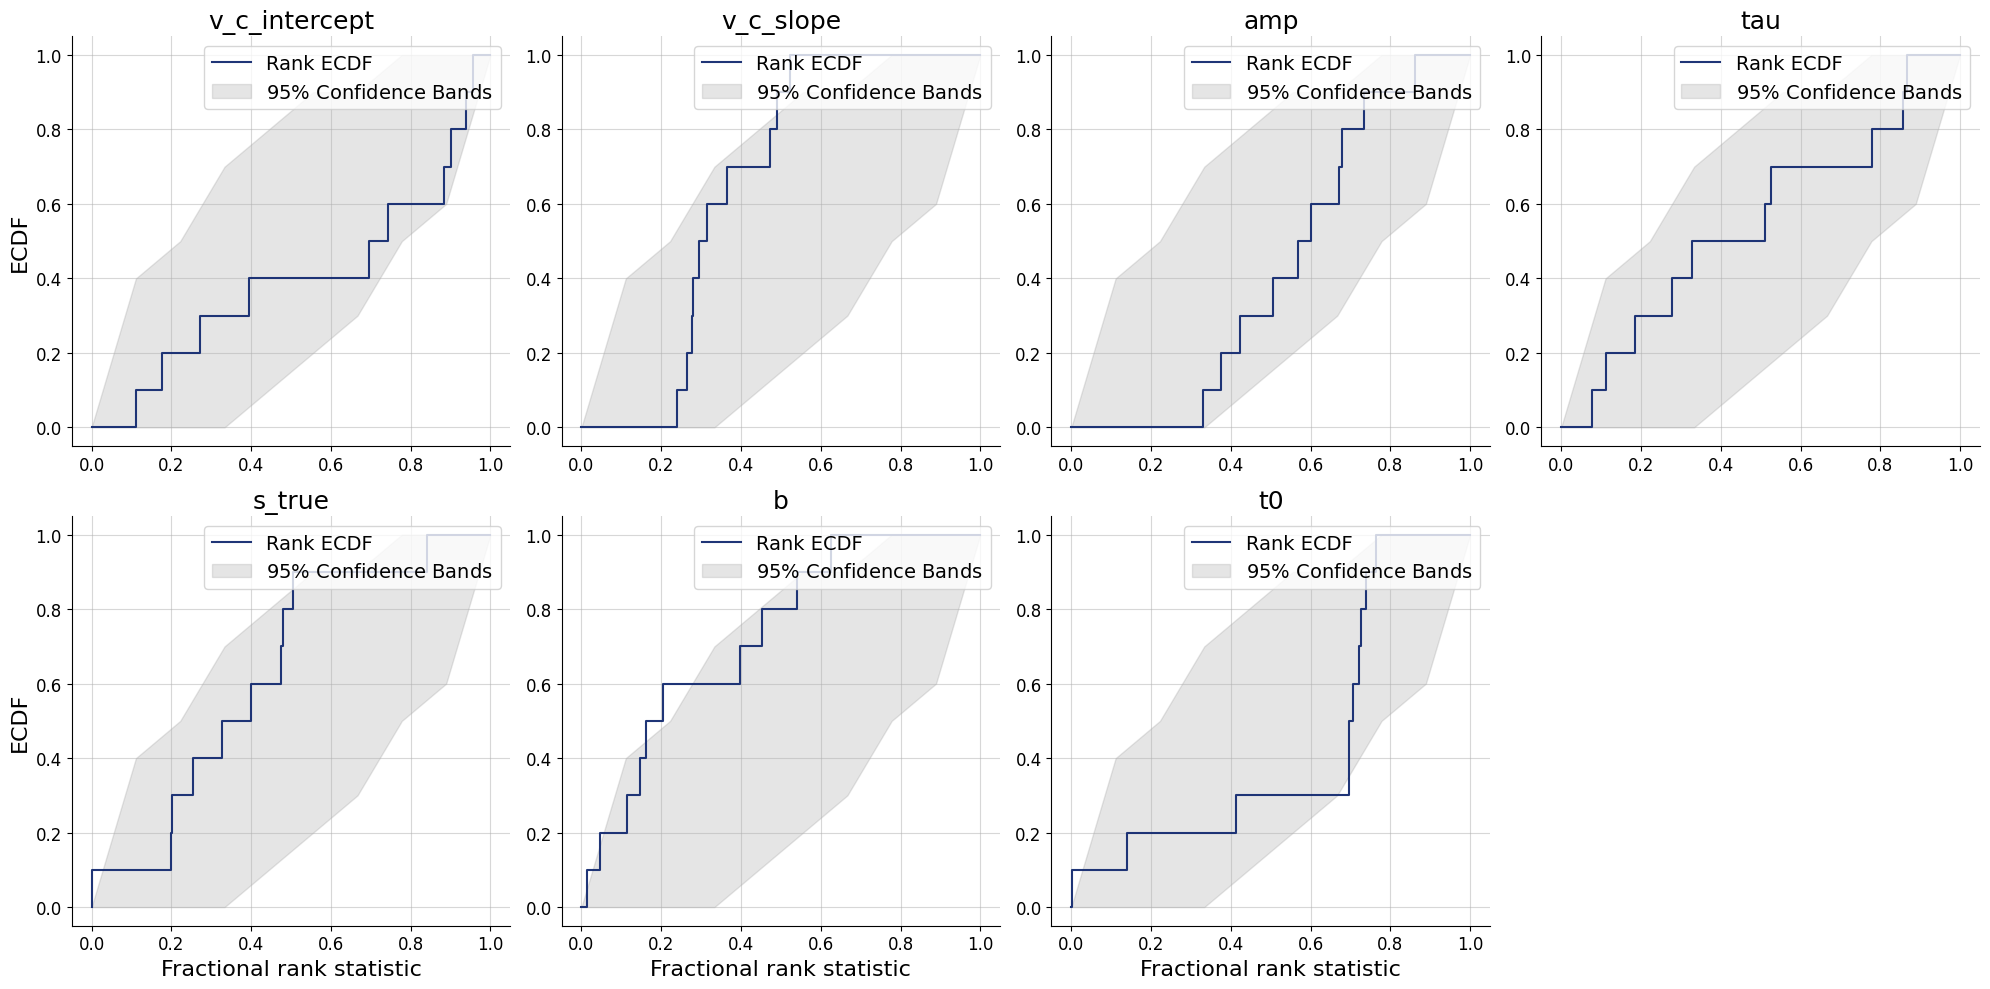

In [43]:
import bayesflow.diagnostics.plots as bf_plots

bf_plots.calibration_ecdf(np.moveaxis(np.asarray(theta), 0, 1), np.asarray(true_theta), variable_names=SUBJ_PARAM_NAMES);

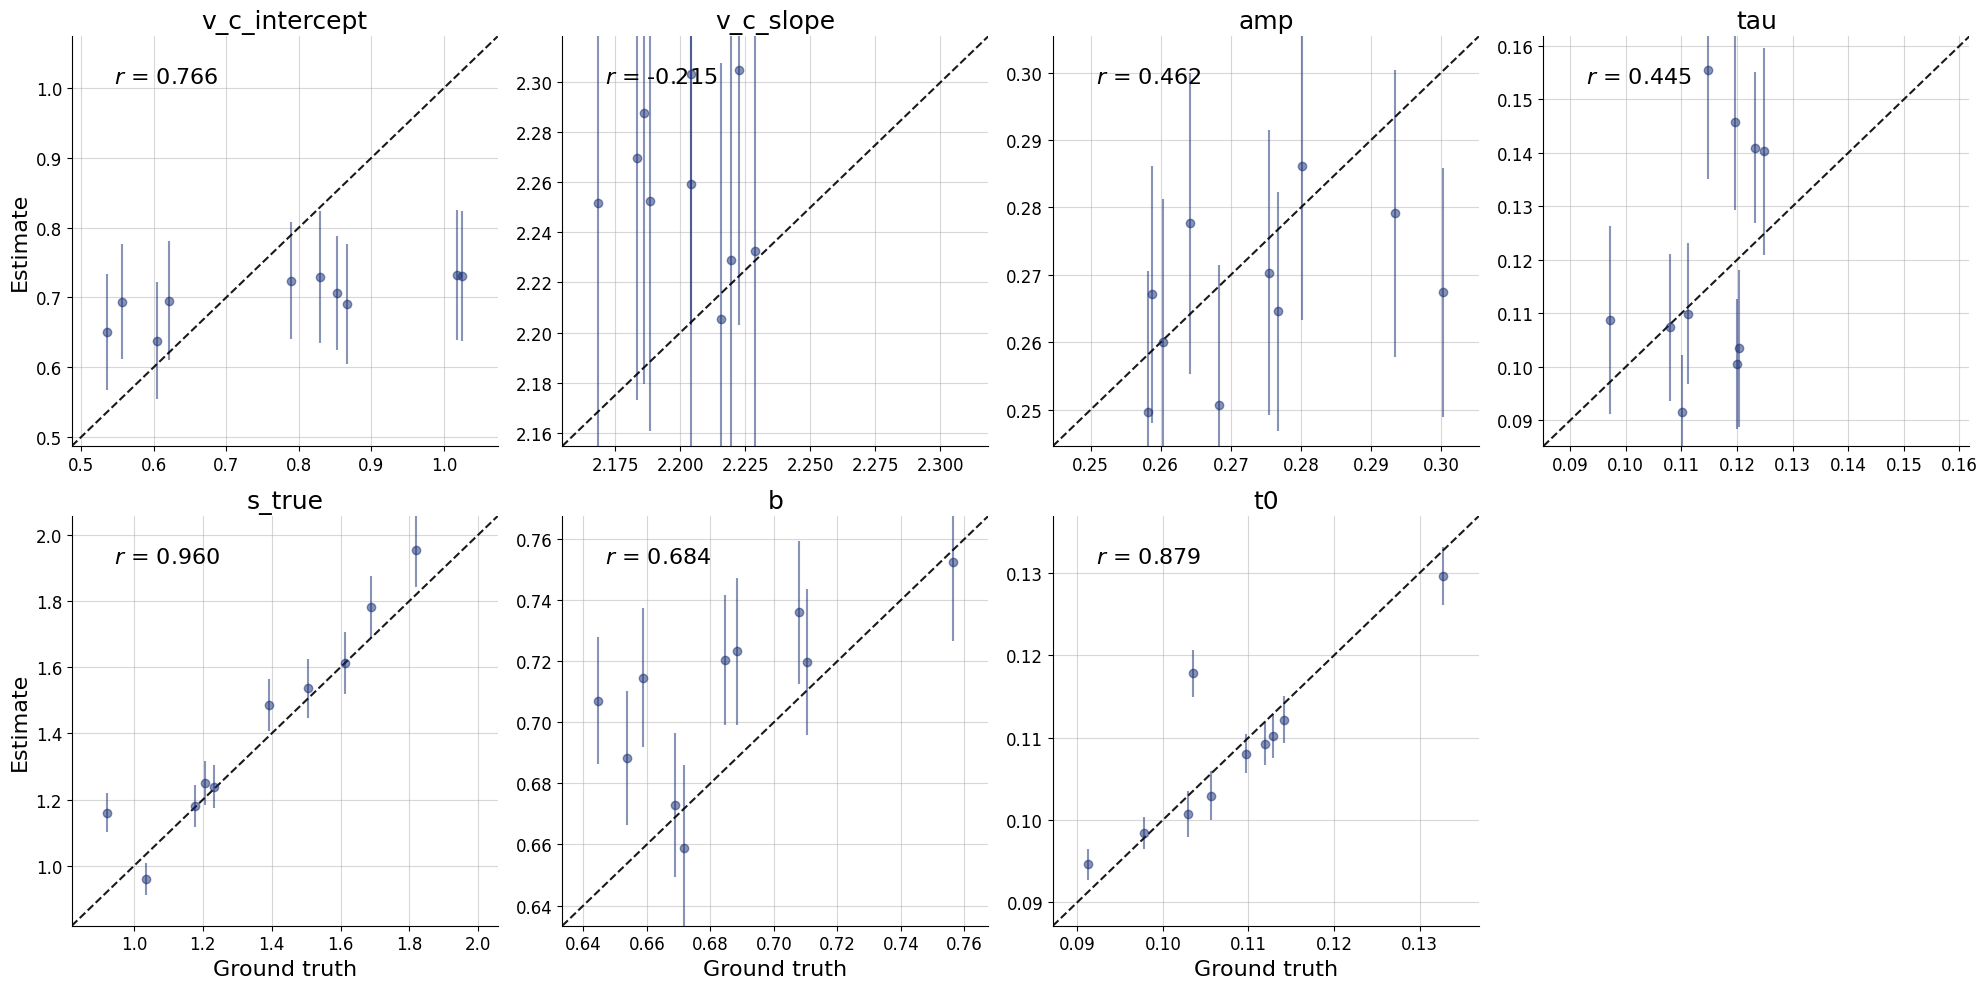

In [44]:
import bayesflow.diagnostics.plots as bf_plots

bf_plots.recovery(np.moveaxis(np.asarray(theta), 0, 1), np.asarray(true_theta), variable_names=SUBJ_PARAM_NAMES);

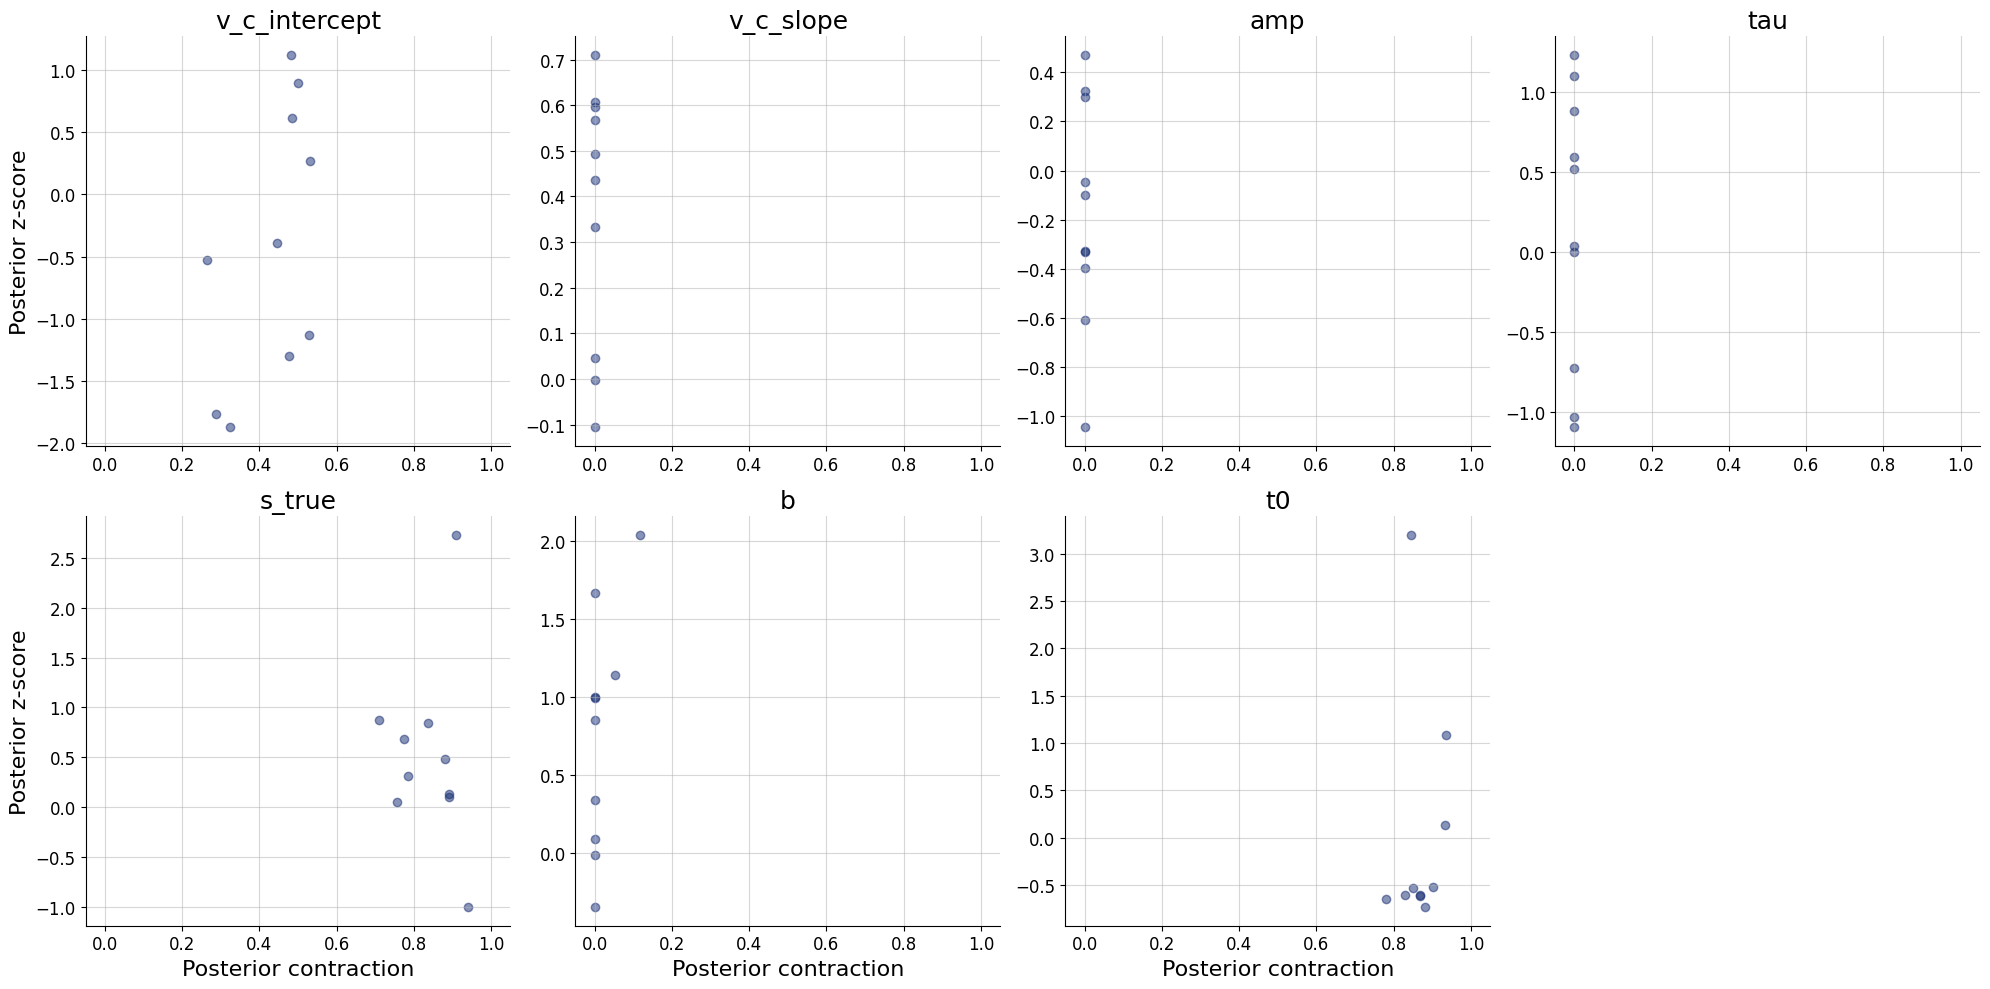

In [46]:
import bayesflow.diagnostics.plots as bf_plots

bf_plots.z_score_contraction(np.moveaxis(np.asarray(theta), 0, 1), np.asarray(true_theta), variable_names=SUBJ_PARAM_NAMES);

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/bayesflow/diagnostics/plots/z_score_contraction.py:117: RuntimeWarning: invalid value encountered in divide
  z_score = (post_means - targets) / post_stds


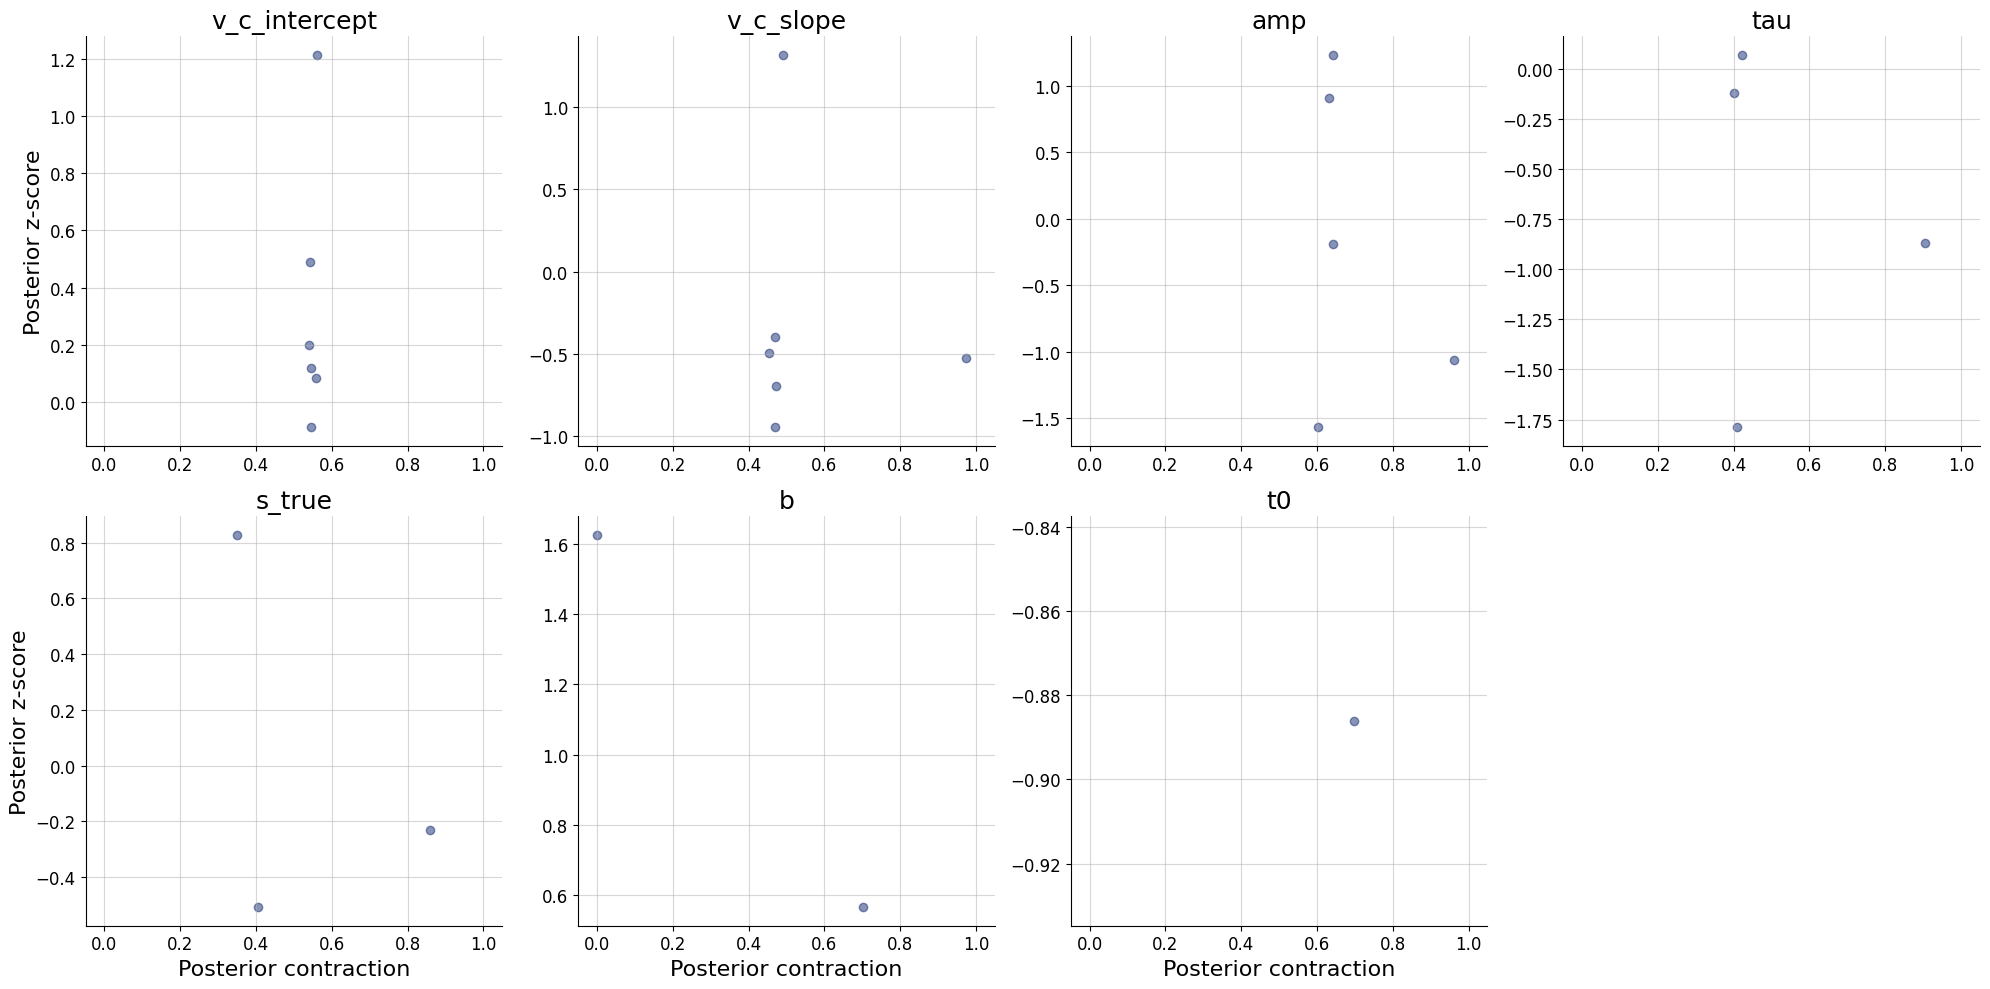

In [47]:
import bayesflow.diagnostics.plots as bf_plots

bf_plots.z_score_contraction(np.moveaxis(np.asarray(params["psi_raw"]), 0, 1), np.asarray(true_psi_raw), variable_names=SUBJ_PARAM_NAMES);

In [48]:
import bayesflow as bf

bf.diagnostics.posterior_contraction(np.asarray(params["s"]), true_s)

{'values': VariableArray(0.),
 'metric_name': 'Posterior Contraction',
 'variable_names': ['v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6']}

In [49]:
bf.diagnostics.posterior_contraction(np.asarray(params["mu"]), true_mu)

{'values': VariableArray(0.),
 'metric_name': 'Posterior Contraction',
 'variable_names': ['v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6']}

## 4. Helper: weighted quantiles

In [50]:
def weighted_quantile(values, weights, q):
    """Compute weighted quantile(s) along axis 0.

    Args:
        values: (N,) array.
        weights: (N,) normalized weights.
        q: scalar or array of quantiles in [0, 1].

    Returns:
        Quantile value(s).
    """
    q = np.atleast_1d(q)
    idx = np.argsort(values)
    sorted_vals = values[idx]
    sorted_w = weights[idx]
    cum_w = np.cumsum(sorted_w)
    # Normalize cumulative weights to [0, 1]
    cum_w = (cum_w - 0.5 * sorted_w[idx]) / cum_w[-1]
    return np.interp(q, cum_w, sorted_vals)


def weighted_mean(values, weights):
    """Weighted mean along axis 0."""
    return np.average(values, weights=weights, axis=0)


def ess_from_weights(log_weights):
    """Compute effective sample size from log-weights."""
    log_w = log_weights - np.max(log_weights)
    w = np.exp(log_w)
    w = w / w.sum()
    return 1.0 / np.sum(w ** 2)

## 5. Diagnostics

In [51]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    particles_raw = pop["particles_raw"]  # (chains, particles, D)
    weights_raw = pop["weights_raw"]
    num_chains = particles_raw.shape[0]

    print(f"=== Population {pop_idx} ===")

    # ESS per chain
    for c in range(num_chains):
        ess = ess_from_weights(weights_raw[c])
        print(f"  Chain {c}: ESS = {ess:.1f} / {particles_raw.shape[1]} particles")

    # R-hat across chains (requires > 1 chain)
    if num_chains > 1:
        # blackjax expects (datasets, samples, chains, params)
        # Our shape is (chains, particles, D) -> need (particles, chains, D)
        particles_for_rhat = np.moveaxis(particles_raw, 0, 1)  # (particles, chains, D)
        rhat = blackjax.diagnostics.potential_scale_reduction(
            particles_raw, chain_axis=0, sample_axis=1
        )
        rhat_np = np.asarray(rhat)
        print(f"  R-hat range: [{rhat_np.min():.4f}, {rhat_np.max():.4f}]")
        print(f"  R-hat > 1.01: {(rhat_np > 1.01).sum()} / {rhat_np.size} params")
        print(f"  R-hat > 1.1:  {(rhat_np > 1.1).sum()} / {rhat_np.size} params")
    else:
        print("  R-hat: only 1 chain, skipping")

=== Population 0 ===
  Chain 0: ESS = 1000.0 / 1000 particles
  Chain 1: ESS = 1000.0 / 1000 particles
  Chain 2: ESS = 1000.0 / 1000 particles
  Chain 3: ESS = 1000.0 / 1000 particles
  R-hat range: [0.9995, 1.0032]
  R-hat > 1.01: 0 / 105 params
  R-hat > 1.1:  0 / 105 params


## 6. Population-level recovery: mu and s

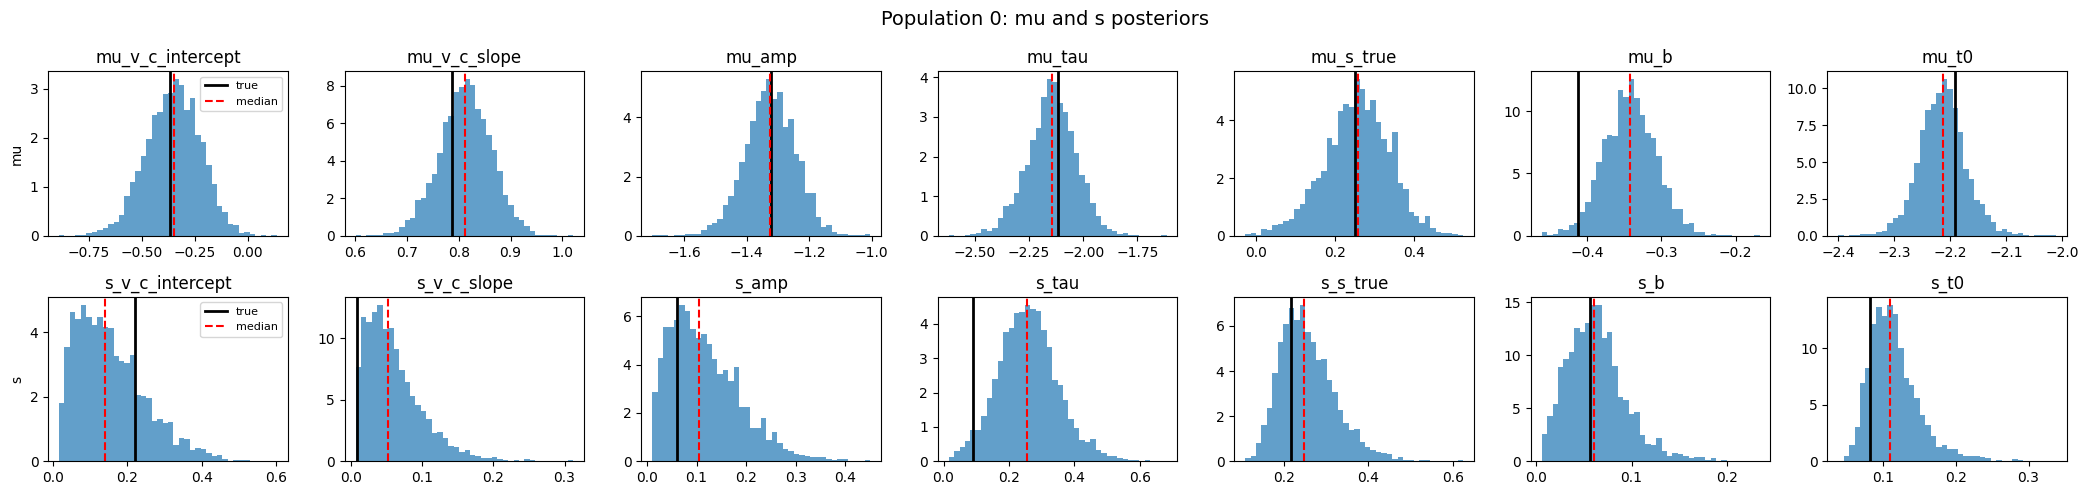

In [52]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    w = pop["w"]
    mu_samples = pop["params"]["mu"]  # (N, P)
    s_samples = pop["params"]["s"]    # (N, P)
    true_mu = pop["true_mu"]
    true_s = pop["true_s"]

    fig, axes = plt.subplots(2, P, figsize=(3 * P, 5))
    fig.suptitle(f"Population {pop_idx}: mu and s posteriors", fontsize=14)

    for i in range(P):
        # mu posterior
        ax = axes[0, i]
        ax.hist(mu_samples[:, i], bins=40, weights=w, density=True, alpha=0.7)
        ax.axvline(true_mu[i], color="k", linewidth=2, label="true")
        med = weighted_quantile(mu_samples[:, i], w, 0.5)[0]
        ax.axvline(med, color="red", linestyle="--", label="median")
        ax.set_title(MU_PARAM_NAMES[i])
        if i == 0:
            ax.set_ylabel("mu")
            ax.legend(fontsize=8)

        # s posterior
        ax = axes[1, i]
        ax.hist(s_samples[:, i], bins=40, weights=w, density=True, alpha=0.7)
        ax.axvline(true_s[i], color="k", linewidth=2, label="true")
        med = weighted_quantile(s_samples[:, i], w, 0.5)[0]
        ax.axvline(med, color="red", linestyle="--", label="median")
        ax.set_title(S_PARAM_NAMES[i])
        if i == 0:
            ax.set_ylabel("s")
            ax.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

## 7. Population-level recovery: correlation matrix

/tmp/ipykernel_71710/963880164.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


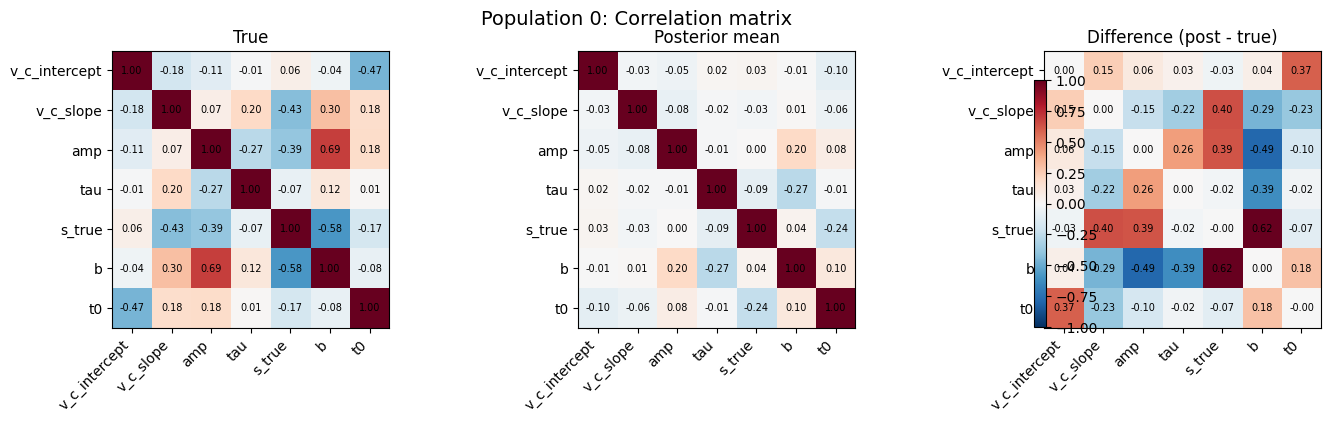

In [53]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    w = pop["w"]
    corr_samples = pop["corr"]  # (N, P, P)
    true_corr = pop["true_corr"]

    # Weighted mean correlation matrix
    post_corr = np.average(corr_samples, weights=w, axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Population {pop_idx}: Correlation matrix", fontsize=14)

    vmin, vmax = -1, 1
    im = axes[0].imshow(true_corr, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    axes[0].set_title("True")
    axes[0].set_xticks(range(P), SUBJ_PARAM_NAMES, rotation=45, ha="right")
    axes[0].set_yticks(range(P), SUBJ_PARAM_NAMES)

    axes[1].imshow(post_corr, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    axes[1].set_title("Posterior mean")
    axes[1].set_xticks(range(P), SUBJ_PARAM_NAMES, rotation=45, ha="right")
    axes[1].set_yticks(range(P), SUBJ_PARAM_NAMES)

    diff = post_corr - true_corr
    max_abs = max(np.abs(diff).max(), 0.01)
    axes[2].imshow(diff, cmap="RdBu_r", vmin=-max_abs, vmax=max_abs)
    axes[2].set_title("Difference (post - true)")
    axes[2].set_xticks(range(P), SUBJ_PARAM_NAMES, rotation=45, ha="right")
    axes[2].set_yticks(range(P), SUBJ_PARAM_NAMES)

    # Add text annotations
    for ax, mat in zip(axes, [true_corr, post_corr, diff]):
        for i in range(P):
            for j in range(P):
                ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=axes, shrink=0.8)
    fig.tight_layout()
    plt.show()

## 8. Subject-level recovery: theta

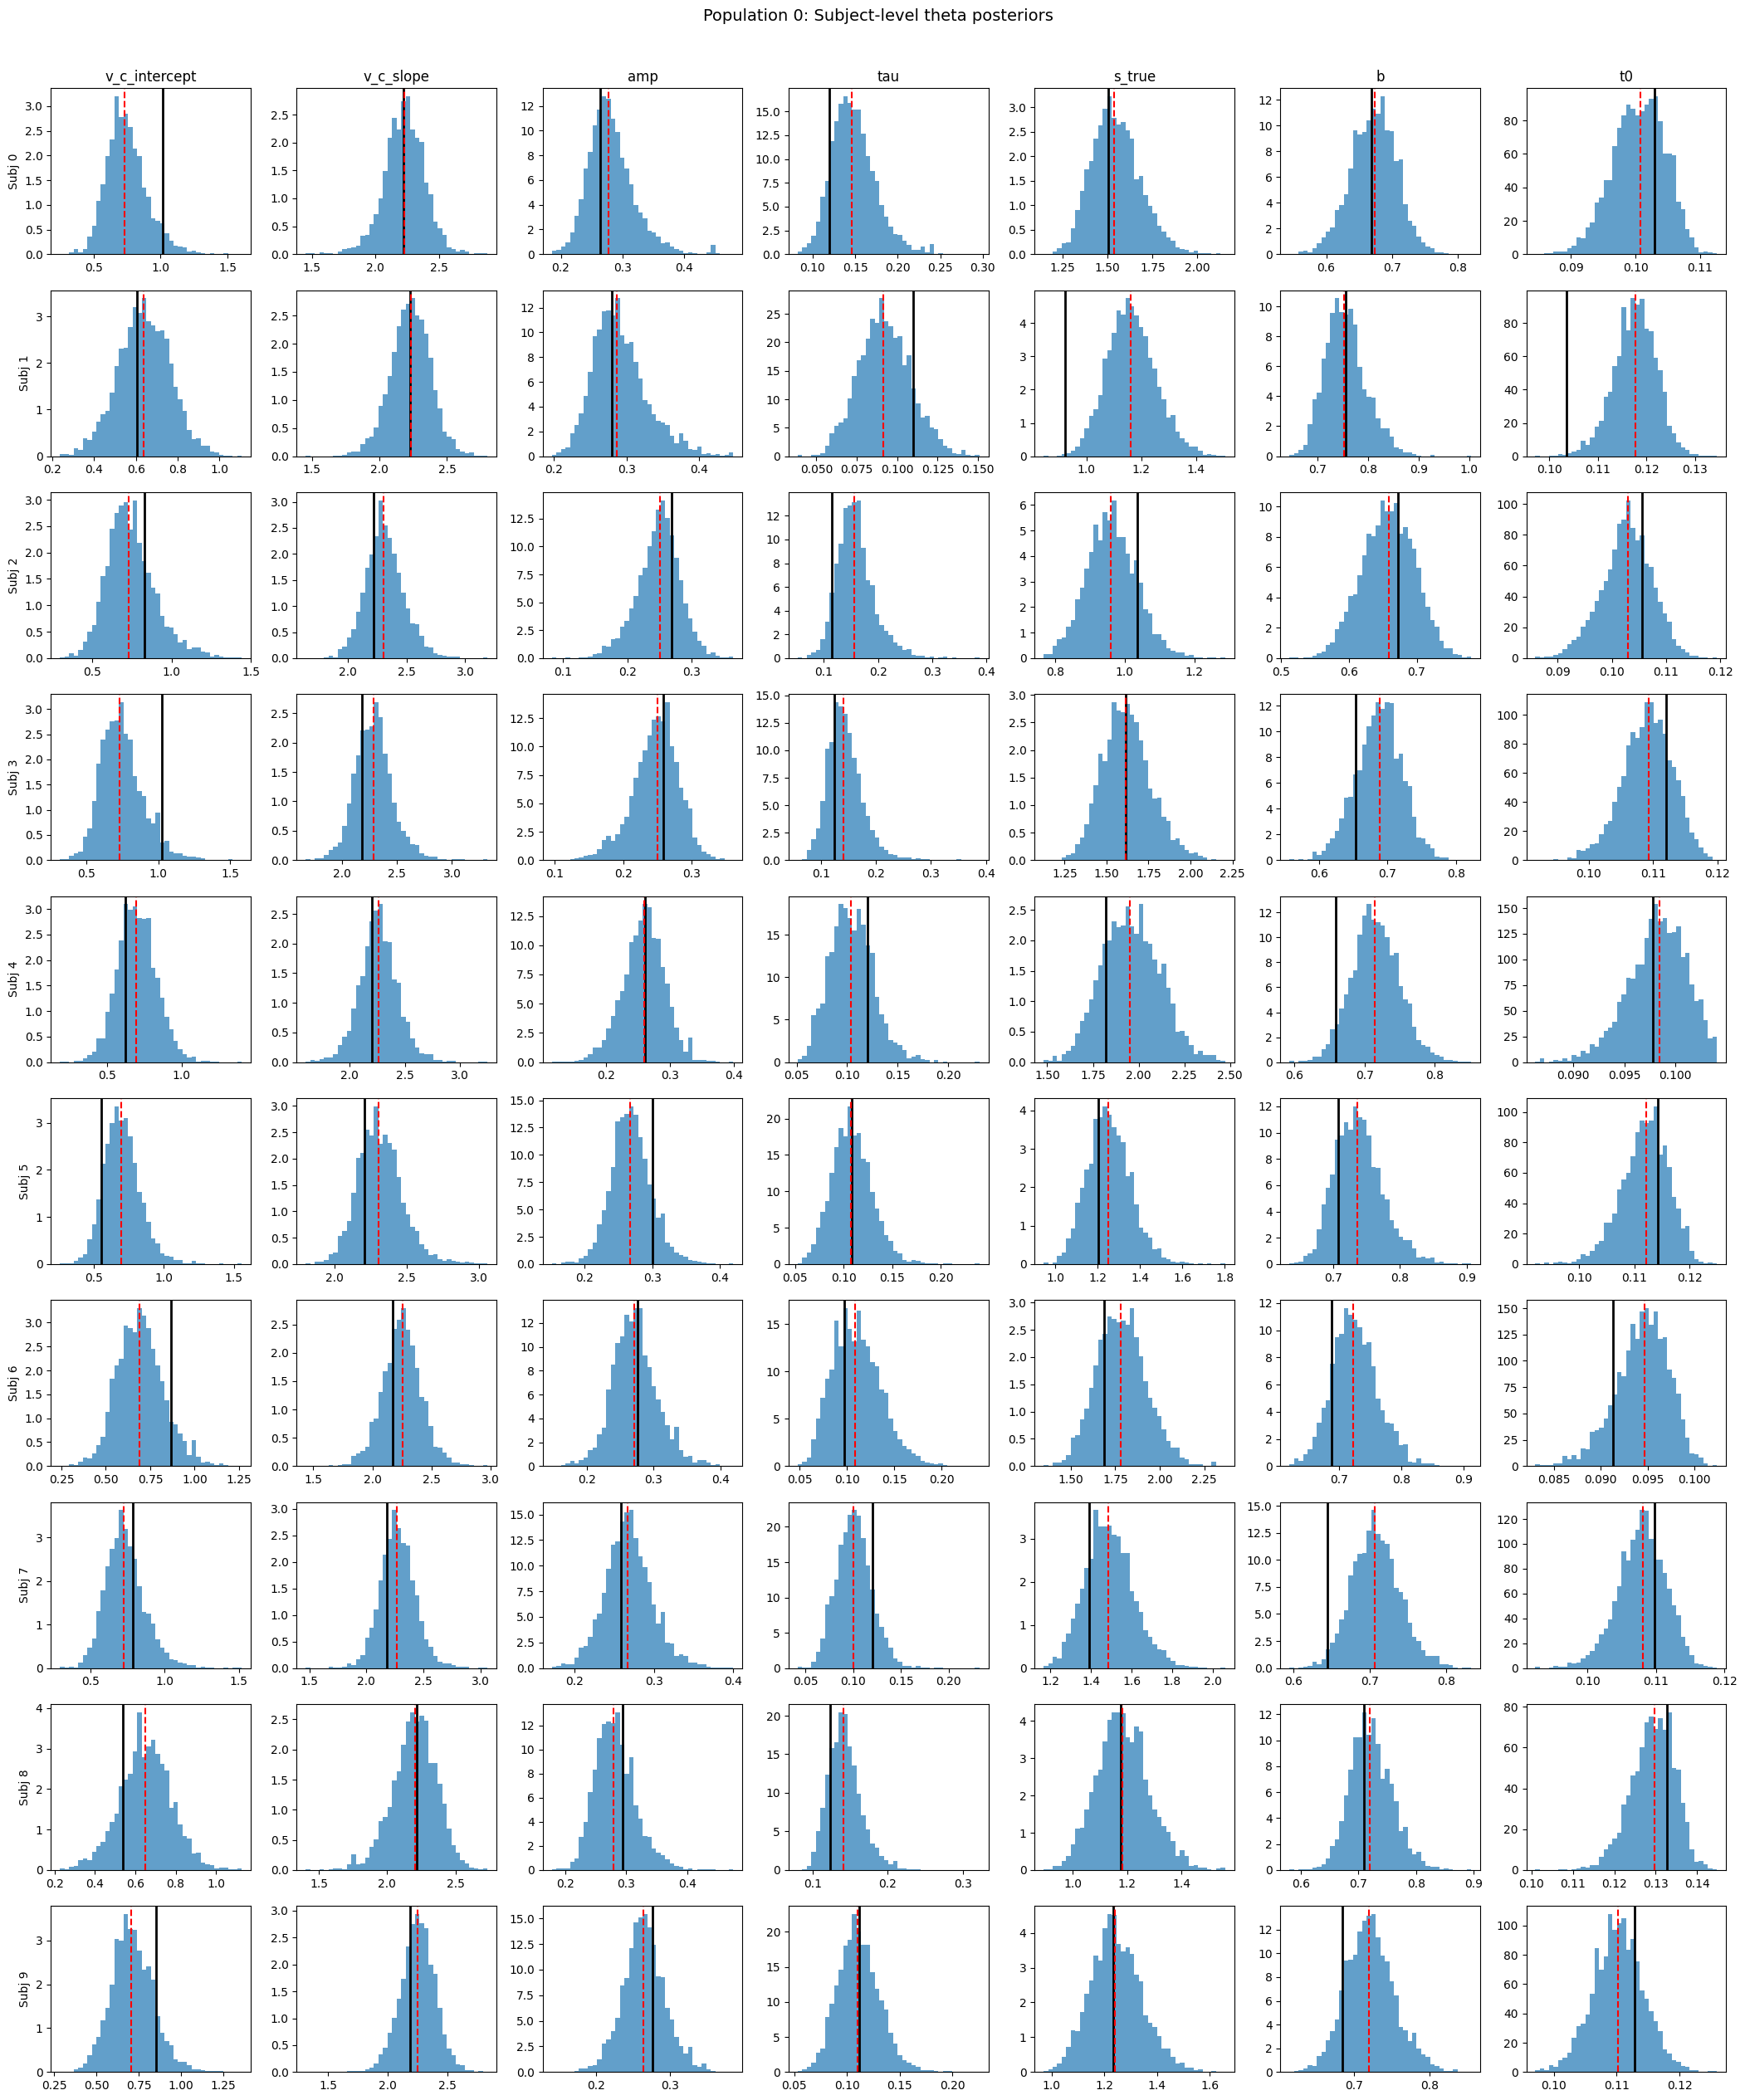

In [54]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    w = pop["w"]
    theta = pop["theta"]          # (N, S, P)
    true_theta = pop["true_theta"]  # (S, P)
    S = true_theta.shape[0]

    fig, axes = plt.subplots(S, P, figsize=(3 * P, 2.5 * S))
    if S == 1:
        axes = axes[None, :]
    fig.suptitle(f"Population {pop_idx}: Subject-level theta posteriors", fontsize=14, y=1.01)

    for s in range(S):
        for p in range(P):
            ax = axes[s, p]
            ax.hist(theta[:, s, p], bins=40, weights=w, density=True, alpha=0.7)
            ax.axvline(true_theta[s, p], color="k", linewidth=2)
            med = weighted_quantile(theta[:, s, p], w, 0.5)[0]
            ax.axvline(med, color="red", linestyle="--")
            if s == 0:
                ax.set_title(SUBJ_PARAM_NAMES[p])
            if p == 0:
                ax.set_ylabel(f"Subj {s}")

    fig.tight_layout()
    plt.show()

## 9. Subject-level recovery scatter: posterior median vs true

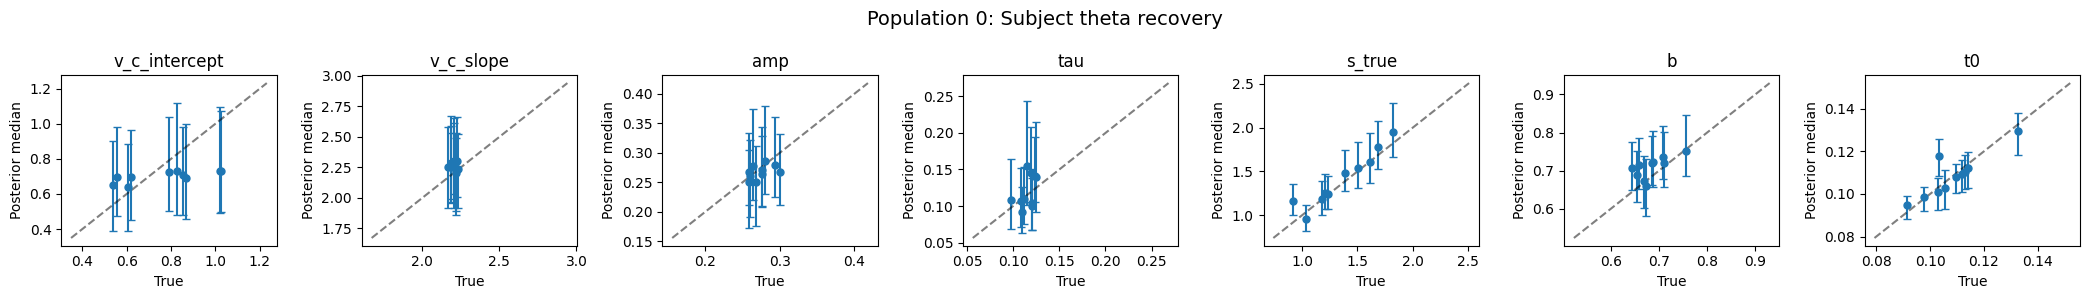

In [55]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    w = pop["w"]
    theta = pop["theta"]            # (N, S, P)
    true_theta = pop["true_theta"]  # (S, P)
    S = true_theta.shape[0]

    fig, axes = plt.subplots(1, P, figsize=(3 * P, 3))
    fig.suptitle(f"Population {pop_idx}: Subject theta recovery", fontsize=14)

    for p in range(P):
        ax = axes[p]
        post_med = np.array([weighted_quantile(theta[:, s, p], w, 0.5)[0] for s in range(S)])
        lo = np.array([weighted_quantile(theta[:, s, p], w, 0.025)[0] for s in range(S)])
        hi = np.array([weighted_quantile(theta[:, s, p], w, 0.975)[0] for s in range(S)])

        ax.errorbar(
            true_theta[:, p], post_med,
            yerr=[post_med - lo, hi - post_med],
            fmt="o", capsize=3, markersize=5,
        )
        lims = [
            min(true_theta[:, p].min(), lo.min()) * 0.9,
            max(true_theta[:, p].max(), hi.max()) * 1.1,
        ]
        ax.plot(lims, lims, "k--", alpha=0.5)
        ax.set_xlabel("True")
        ax.set_ylabel("Posterior median")
        ax.set_title(SUBJ_PARAM_NAMES[p])

    fig.tight_layout()
    plt.show()

## 10. Subject-level credible interval coverage

In [56]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    w = pop["w"]
    theta = pop["theta"]
    true_theta = pop["true_theta"]
    S = true_theta.shape[0]

    print(f"=== Population {pop_idx}: 95% CI coverage ===")
    for p in range(P):
        covered = 0
        for s in range(S):
            lo, hi = weighted_quantile(theta[:, s, p], w, [0.025, 0.975])
            if lo <= true_theta[s, p] <= hi:
                covered += 1
        print(f"  {SUBJ_PARAM_NAMES[p]:>15s}: {covered}/{S} ({100 * covered / S:.0f}%)")

=== Population 0: 95% CI coverage ===
    v_c_intercept: 10/10 (100%)
        v_c_slope: 10/10 (100%)
              amp: 10/10 (100%)
              tau: 10/10 (100%)
           s_true: 9/10 (90%)
                b: 9/10 (90%)
               t0: 9/10 (90%)


## 10b. Subject-level posterior contraction

Posterior contraction measures how much the data informs each subject's
parameters beyond the group-level prior. Contraction is defined as
`1 - posterior_sd / prior_sd`, where `prior_sd` is the population-level
scale parameter `s`. Values near 1 indicate strong learning from data;
values near 0 indicate the posterior is close to the prior.

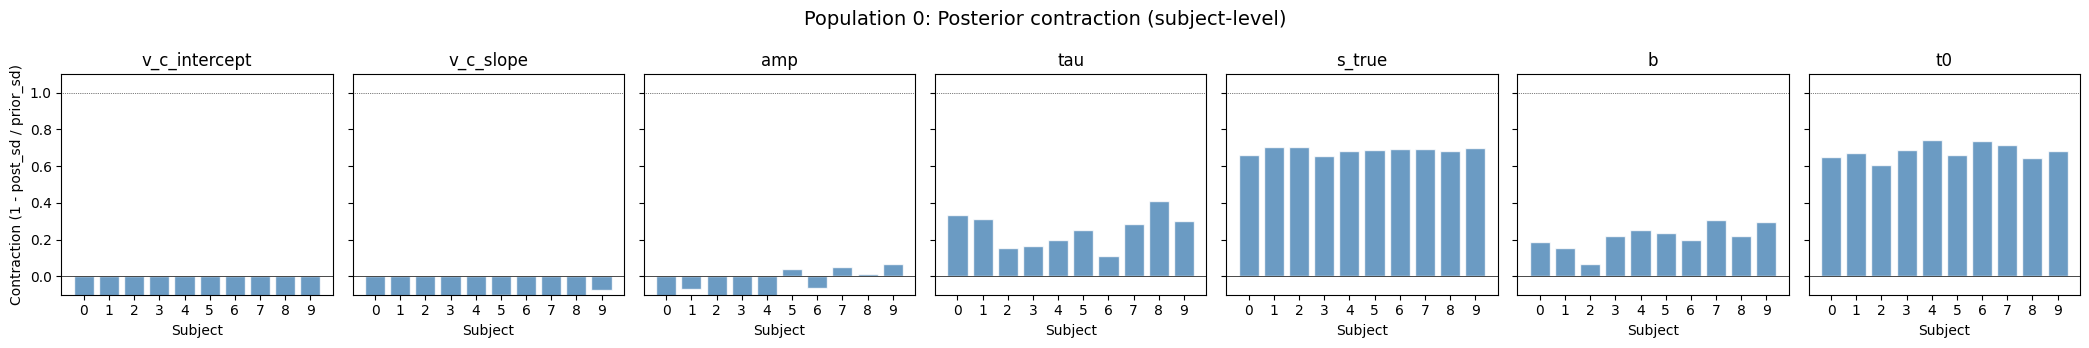

=== Population 0: Mean contraction across subjects ===
    v_c_intercept: -0.247 (range: -0.339 - -0.127)
        v_c_slope: -0.178 (range: -0.281 - -0.073)
              amp: -0.062 (range: -0.232 - 0.067)
              tau: 0.253 (range: 0.113 - 0.410)
           s_true: 0.687 (range: 0.654 - 0.707)
                b: 0.213 (range: 0.066 - 0.305)
               t0: 0.681 (range: 0.607 - 0.745)


In [57]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    w = pop["w"]
    log_theta = pop["log_theta"]  # (N, S, P)
    s_samples = pop["params"]["s"]  # (N, P)
    true_theta = pop["true_theta"]
    S = true_theta.shape[0]

    # Prior SD: posterior mean of population-level scale s
    prior_sd = weighted_mean(s_samples, w)  # (P,)

    # Posterior SD per subject per parameter (in log space)
    post_mean = np.array([
        [weighted_mean(log_theta[:, s, p], w) for p in range(P)]
        for s in range(S)
    ])  # (S, P)
    post_sd = np.array([
        [np.sqrt(weighted_mean((log_theta[:, s, p] - post_mean[s, p]) ** 2, w)) for p in range(P)]
        for s in range(S)
    ])  # (S, P)

    # Contraction ratio
    contraction = 1.0 - post_sd / prior_sd[None, :]  # (S, P)

    fig, axes = plt.subplots(1, P, figsize=(3 * P, 3.5), sharey=True)
    fig.suptitle(f"Population {pop_idx}: Posterior contraction (subject-level)", fontsize=14)

    for p in range(P):
        ax = axes[p]
        x = np.arange(S)
        ax.bar(x, contraction[:, p], color="steelblue", alpha=0.8, edgecolor="white")
        ax.axhline(0, color="k", linewidth=0.5)
        ax.axhline(1, color="k", linewidth=0.5, linestyle=":")
        ax.set_title(SUBJ_PARAM_NAMES[p])
        ax.set_xlabel("Subject")
        ax.set_xticks(x)
        ax.set_ylim(-0.1, 1.1)
        if p == 0:
            ax.set_ylabel("Contraction (1 - post_sd / prior_sd)")

    fig.tight_layout()
    plt.show()

    # Print summary
    print(f"=== Population {pop_idx}: Mean contraction across subjects ===")
    for p in range(P):
        print(f"  {SUBJ_PARAM_NAMES[p]:>15s}: {contraction[:, p].mean():.3f} "
              f"(range: {contraction[:, p].min():.3f} - {contraction[:, p].max():.3f})")

## 11. ArviZ trace plots for population parameters

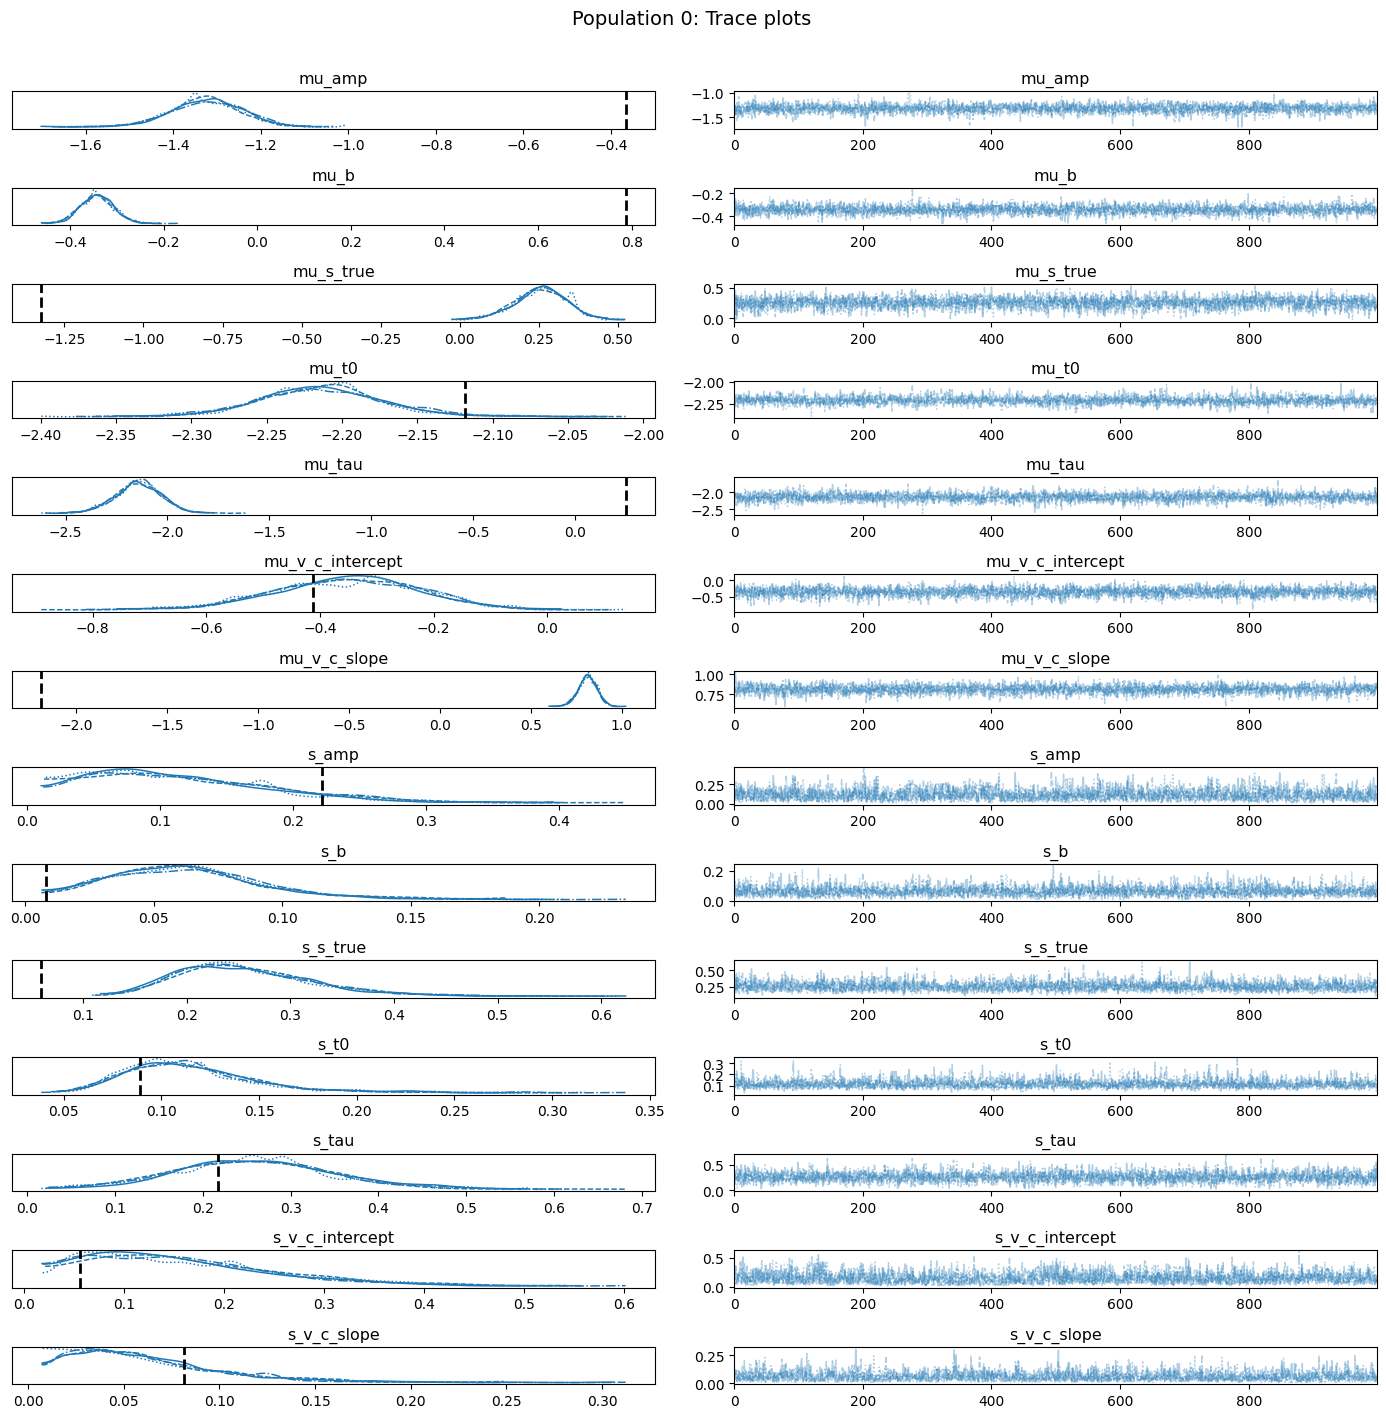

In [58]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    particles_raw = pop["particles_raw"]  # (chains, particles, D)
    num_chains = particles_raw.shape[0]

    # Transform each chain's particles to constrained space
    chain_mu = []
    chain_s = []
    for c in range(num_chains):
        p_c = particles_to_params(jnp.array(particles_raw[c]))
        chain_mu.append(np.asarray(p_c["mu"]))  # (particles, P)
        chain_s.append(np.asarray(p_c["s"]))    # (particles, P)

    # ArviZ expects dict of {name: (chains, samples)}
    mu_dict = {
        MU_PARAM_NAMES[i]: np.stack([cm[:, i] for cm in chain_mu], axis=0)
        for i in range(P)
    }
    s_dict = {
        S_PARAM_NAMES[i]: np.stack([cs[:, i] for cs in chain_s], axis=0)
        for i in range(P)
    }

    idata = az.convert_to_inference_data({**mu_dict, **s_dict})
    ax = az.plot_trace(idata, figsize=(14, 2 * P))

    # Mark true values on density plots
    true_mu = pop["true_mu"]
    true_s = pop["true_s"]
    all_names = MU_PARAM_NAMES + S_PARAM_NAMES
    all_true = list(true_mu) + list(true_s)
    for i, (name, val) in enumerate(zip(all_names, all_true)):
        ax[i, 0].axvline(float(val), color="k", linewidth=2, linestyle="--")

    plt.suptitle(f"Population {pop_idx}: Trace plots", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## 12. Summary table

In [59]:
for pop_idx in range(NUM_POPULATIONS):
    pop = populations[pop_idx]
    w = pop["w"]
    true_mu = pop["true_mu"]
    true_s = pop["true_s"]
    mu_samples = pop["params"]["mu"]
    s_samples = pop["params"]["s"]

    print(f"=== Population {pop_idx}: Population parameter summary ===")
    print(f"{'Parameter':>15s}  {'True':>8s}  {'Mean':>8s}  {'Median':>8s}  {'2.5%':>8s}  {'97.5%':>8s}")
    print("-" * 70)

    for i in range(P):
        vals = mu_samples[:, i]
        lo, med, hi = weighted_quantile(vals, w, [0.025, 0.5, 0.975])
        mn = weighted_mean(vals, w)
        print(f"{MU_PARAM_NAMES[i]:>15s}  {true_mu[i]:8.4f}  {mn:8.4f}  {med:8.4f}  {lo:8.4f}  {hi:8.4f}")

    for i in range(P):
        vals = s_samples[:, i]
        lo, med, hi = weighted_quantile(vals, w, [0.025, 0.5, 0.975])
        mn = weighted_mean(vals, w)
        print(f"{S_PARAM_NAMES[i]:>15s}  {true_s[i]:8.4f}  {mn:8.4f}  {med:8.4f}  {lo:8.4f}  {hi:8.4f}")

=== Population 0: Population parameter summary ===
      Parameter      True      Mean    Median      2.5%     97.5%
----------------------------------------------------------------------
mu_v_c_intercept   -0.3662   -0.3509   -0.3464   -0.6029   -0.1111
   mu_v_c_slope    0.7872    0.8127    0.8130    0.7103    0.9097
         mu_amp   -1.3229   -1.3253   -1.3250   -1.4885   -1.1753
         mu_tau   -2.1181   -2.1443   -2.1424   -2.3720   -1.9298
      mu_s_true    0.2500    0.2562    0.2591    0.0803    0.4152
           mu_b   -0.4119   -0.3422   -0.3428   -0.4094   -0.2718
          mu_t0   -2.1909   -2.2138   -2.2139   -2.2966   -2.1289
s_v_c_intercept    0.2217    0.1566    0.1404    0.0299    0.3817
    s_v_c_slope    0.0082    0.0608    0.0519    0.0108    0.1617
          s_amp    0.0596    0.1177    0.1052    0.0194    0.2837
          s_tau    0.0891    0.2591    0.2559    0.0864    0.4550
       s_s_true    0.2169    0.2568    0.2471    0.1543    0.4106
            s_b    

## 13. Data overview

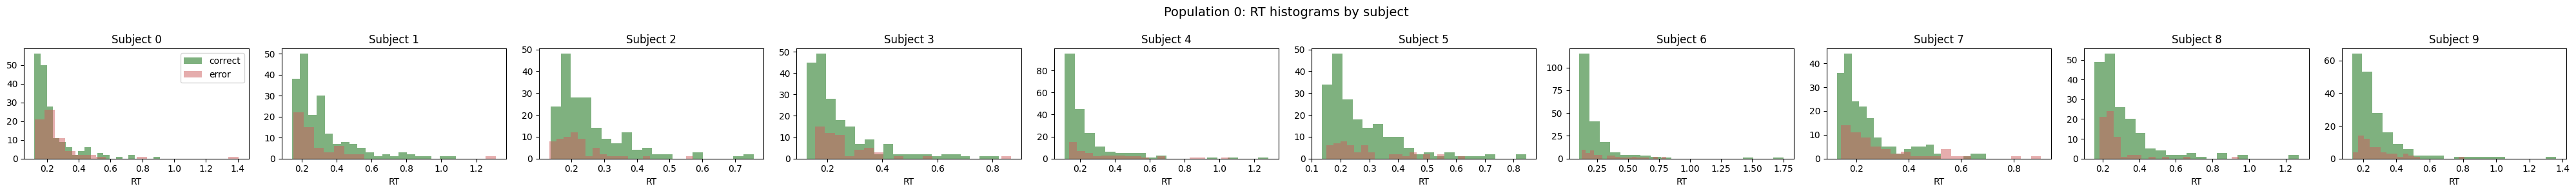

In [60]:
for pop_idx in range(NUM_POPULATIONS):
    data = populations[pop_idx]["data"]
    S = data.shape[0]
    fig, axes = plt.subplots(1, S, figsize=(4 * S, 3))
    if S == 1:
        axes = [axes]
    fig.suptitle(f"Population {pop_idx}: RT histograms by subject", fontsize=14)

    for s in range(S):
        ax = axes[s]
        rt = data[s, :, 0]
        choice = data[s, :, 1]
        ax.hist(rt[choice == 1], bins=20, color="darkgreen", alpha=0.5, label="correct")
        ax.hist(rt[choice == 0], bins=20, color="indianred", alpha=0.5, label="error")
        ax.set_title(f"Subject {s}")
        ax.set_xlabel("RT")
        if s == 0:
            ax.legend()

    fig.tight_layout()
    plt.show()